# Introduction to Machine Learning: Deep Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 3: Convolutional Neural Networks (CNNs)

---

## Setup (do not edit)

In [2]:
import pathlib
from typing import Tuple, Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    BatchNormalization, Dropout, GlobalAveragePooling2D, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Suppress TensorFlow warnings for cleaner output
tf.get_logger().setLevel("ERROR")

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# CIFAR-10 class names for reference
CLASS_NAMES: List[str] = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Image dimensions
IMG_HEIGHT: int = 32
IMG_WIDTH: int = 32
IMG_CHANNELS: int = 3
NUM_CLASSES: int = 10

_TRAIN_PATH = pathlib.Path("cifar10_train.csv")
_TEST_PATH = pathlib.Path("cifar10_test.csv")

if not _TRAIN_PATH.exists() or not _TEST_PATH.exists():
    raise FileNotFoundError(
        "CIFAR-10 CSV files are missing from the lab directory. "
        "Please run the download script (w3_download_datasets.py) or ask the TA for assistance."
    )

## 1. Load and Explore the Dataset *(10 points)*

The CIFAR-10 dataset contains 60,000 color images (32×32×3) across 10 classes.
Each image has 3072 pixel values (32 × 32 × 3) plus a label column.

Write a function `load_data()` that:
1. Reads the training CSV into a DataFrame
2. Returns the DataFrame

Store the shape of the training DataFrame in **`q1_shape`**.

In [3]:
def load_data(path: pathlib.Path) -> pd.DataFrame:
    """Load a CIFAR-10 CSV file.

    Parameters
    ----------
    path : pathlib.Path
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame containing pixel values and labels.
    """
    # your code here
    #raise NotImplementedError
    return pd.read_csv(path)

# Load training data and compute answer
train_df = load_data(_TRAIN_PATH)
q1_shape: Tuple[int, int] = train_df.shape

In [4]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert isinstance(q1_shape, tuple), (
    "q1_shape must be a tuple. Use df.shape which returns (rows, cols)."
)
assert len(q1_shape) == 2, (
    "q1_shape should have 2 elements (rows, cols)."
)
assert q1_shape[0] > 0 and q1_shape[1] > 0, (
    "Shape values must be positive. Is your CSV loading correctly?"
)
print(f"Training dataset shape: {q1_shape}")

Training dataset shape: (50000, 3073)


### Exploring the Raw Data (Ungraded)

Before preprocessing, let's visualize what our data looks like. Each image is stored
as 3072 pixel values (32×32×3 = 3072). Let's see how to convert these flat values
back into images.

In [5]:
# Display the first few rows of raw data
print("First 5 rows of training data:")
print(train_df.head())
print(f"\nColumn names: pixel_0 to pixel_3071, plus 'label'")
print(f"Number of samples: {len(train_df):,}")

First 5 rows of training data:
   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0       59       43       50       68       98      119      139      145   
1      154      126      105      102      125      155      172      180   
2      255      253      253      253      253      253      253      253   
3       28       37       38       42       44       40       40       24   
4      170      168      177      183      181      177      181      184   

   pixel_8  pixel_9  ...  pixel_3063  pixel_3064  pixel_3065  pixel_3066  \
0      149      149  ...          58          65          59          46   
1      142      111  ...          42          67         101         122   
2      253      253  ...          83          80          69          66   
3       32       43  ...          39          59          42          44   
4      189      189  ...          88          85          82          83   

   pixel_3067  pixel_3068  pixel_3069  pixel_3070

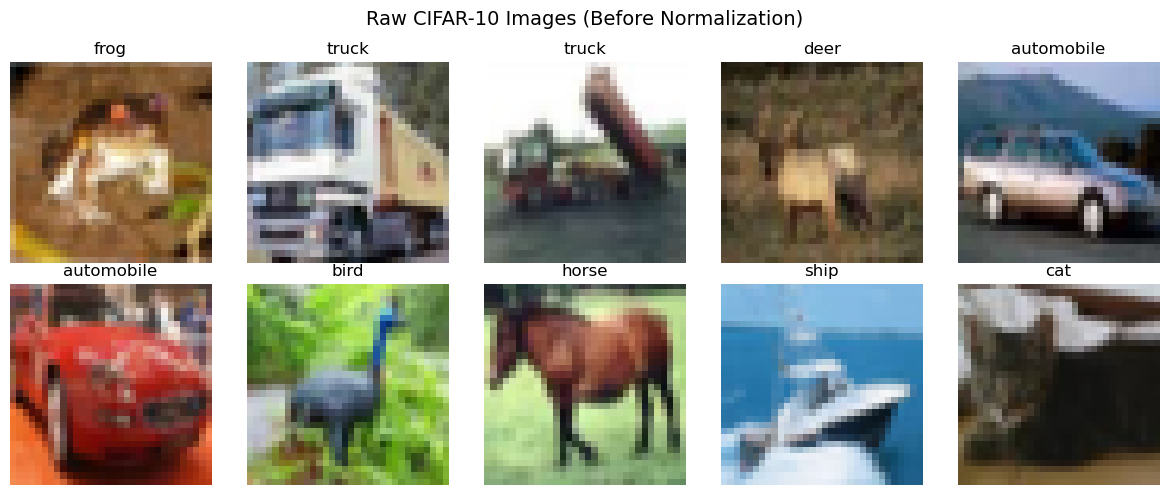

In [6]:
# Visualize raw pixel values as an image
# The pixels are stored as: R channel (1024) + G channel (1024) + B channel (1024)
def flat_to_image(flat_pixels: np.ndarray) -> np.ndarray:
    """Convert 3072 flat pixels to 32x32x3 image."""
    # CIFAR-10 stores pixels as: all R, then all G, then all B
    img = flat_pixels.reshape(3, 32, 32)  # (channels, height, width)
    img = img.transpose(1, 2, 0)  # (height, width, channels)
    return img

# Show a few sample images from raw data
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    pixels = train_df.iloc[idx, :-1].values  # All columns except 'label'
    label = train_df.iloc[idx, -1]  # Last column is label
    img = flat_to_image(pixels)
    ax.imshow(img)
    ax.set_title(f"{CLASS_NAMES[label]}")
    ax.axis('off')
plt.suptitle('Raw CIFAR-10 Images (Before Normalization)', fontsize=14)
plt.tight_layout()
plt.show()

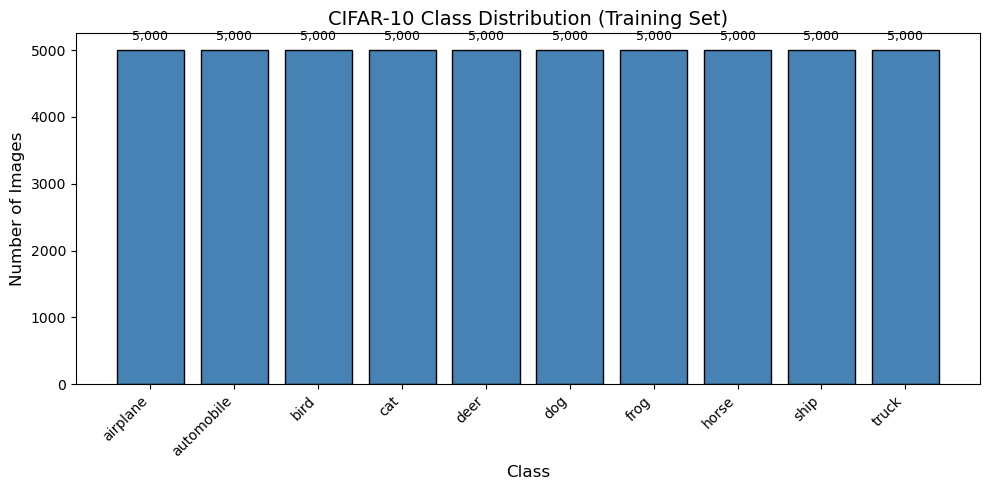

Each class has approximately 5,000 images (balanced dataset)


In [7]:
# Show class distribution
fig, ax = plt.subplots(figsize=(10, 5))
class_counts = train_df['label'].value_counts().sort_index()
bars = ax.bar(CLASS_NAMES, class_counts.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('CIFAR-10 Class Distribution (Training Set)', fontsize=14)
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Each class has approximately {len(train_df)//10:,} images (balanced dataset)")

## 2. Preprocess and Reshape Data *(10 points)*

CNNs expect 4D input: `(samples, height, width, channels)`.

Prepare the data by:
1. Separating features (pixel columns) from the target (label column)
2. Normalizing pixel values to [0, 1] by dividing by 255
3. Reshaping flat pixels to image format: `(N, 32, 32, 3)`
4. Splitting into train (60%), validation (20%), and test (20%) sets

Store:
- **`X_train`**, **`X_val`**, **`X_test`**: Normalized image arrays with shape (N, 32, 32, 3)
- **`y_train`**, **`y_val`**, **`y_test`**: Label arrays
- **`q2_split_counts`**: Tuple of (n_train, n_val, n_test)

**Hint:** Use `reshape(-1, 32, 32, 3)` to convert flat pixels to images.

In [8]:
# Load test data as well
test_df = load_data(_TEST_PATH)

# your code here
#raise NotImplementedError
X = train_df.drop(columns=["label"]).values
y = train_df["label"].values

# Convert to float32 for memory efficiency
X = X.astype("float32") / 255.0

# Reshape to image format
X = X.reshape(-1, 32, 32, 3)

# Split: 60% train, 20% val, 20% test with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

q2_split_counts = (len(X_train), len(X_val), len(X_test))


In [9]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert isinstance(q2_split_counts, tuple), (
    "q2_split_counts must be a tuple (n_train, n_val, n_test)."
)
assert len(q2_split_counts) == 3, "Tuple should have exactly 3 elements."
n_train, n_val, n_test = q2_split_counts
assert all(n > 0 for n in q2_split_counts), (
    "All splits must have positive sample counts."
)
assert n_train > n_val and n_train > n_test, (
    "Training set should be the largest. Check your split ratios."
)
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, (
    "Pixel values should be normalized to [0, 1]. Did you divide by 255?"
)
assert len(X_train.shape) == 4, (
    "X_train should be 4D: (samples, height, width, channels). "
    "Use reshape(-1, 32, 32, 3)."
)
assert X_train.shape[1:] == (32, 32, 3), (
    f"Each image should be (32, 32, 3), got {X_train.shape[1:]}"
)
print(f"Train/Val/Test split: {n_train} / {n_val} / {n_test}")
print(f"Image shape: {X_train.shape[1:]}")

Train/Val/Test split: 30000 / 10000 / 10000
Image shape: (32, 32, 3)


### Visualizing the Preprocessed Data (Ungraded)

Now that we have preprocessed our data, let's visualize it to understand what
CNNs will be working with.

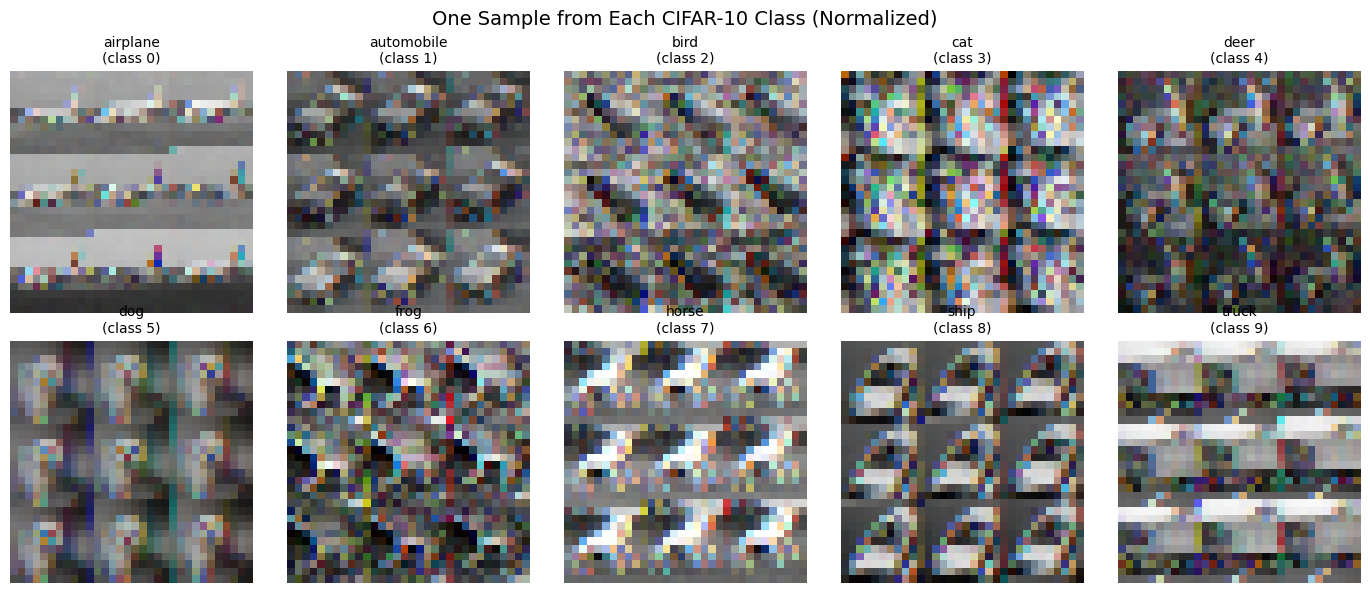

In [10]:
# Show one sample image from each class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for class_idx, ax in enumerate(axes.flat):
    # Find first image of this class
    idx = np.where(y_train == class_idx)[0][0]
    ax.imshow(X_train[idx])
    ax.set_title(f"{CLASS_NAMES[class_idx]}\n(class {class_idx})", fontsize=10)
    ax.axis('off')
plt.suptitle('One Sample from Each CIFAR-10 Class (Normalized)', fontsize=14)
plt.tight_layout()
plt.show()

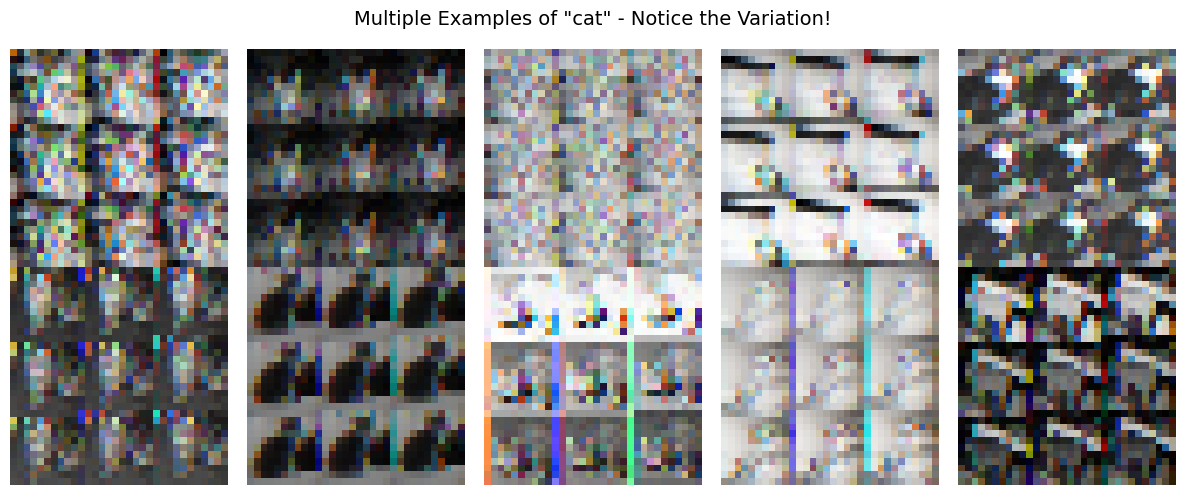

In [11]:
# Show multiple examples of one class to see variation
sample_class = 3  # cat
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
cat_indices = np.where(y_train == sample_class)[0][:10]
for idx, ax in zip(cat_indices, axes.flat):
    ax.imshow(X_train[idx])
    ax.axis('off')
plt.suptitle(f'Multiple Examples of "{CLASS_NAMES[sample_class]}" - Notice the Variation!', fontsize=14)
plt.tight_layout()
plt.show()

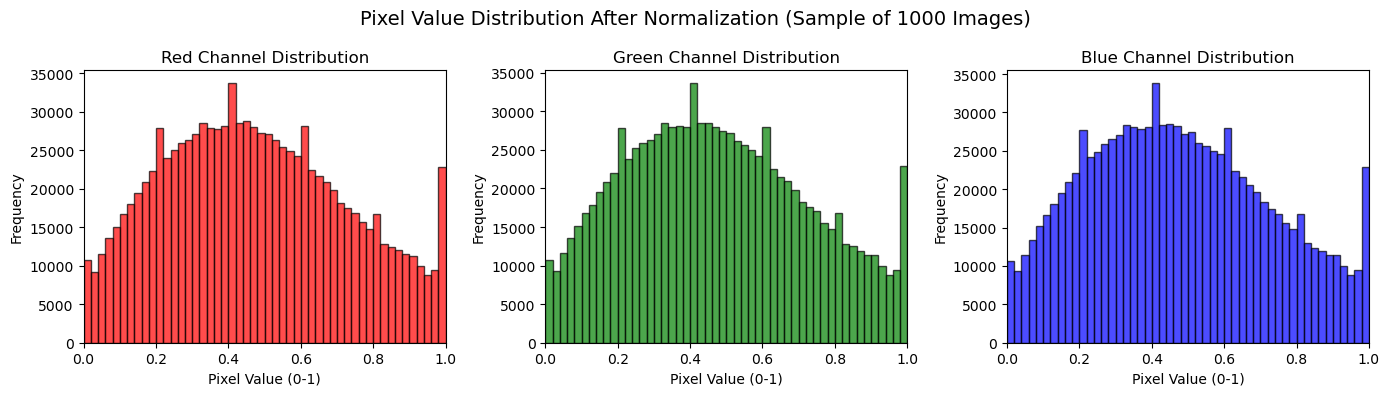

Pixel value range: [0.000, 1.000]
Mean pixel value: 0.474


In [12]:
# Show pixel value distribution after normalization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
channel_names = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']

for i, (ax, name, color) in enumerate(zip(axes, channel_names, colors)):
    # Get all pixel values for this channel
    channel_values = X_train[:1000, :, :, i].flatten()  # Sample 1000 images
    ax.hist(channel_values, bins=50, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Pixel Value (0-1)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{name} Channel Distribution', fontsize=12)
    ax.set_xlim(0, 1)

plt.suptitle('Pixel Value Distribution After Normalization (Sample of 1000 Images)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Pixel value range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Mean pixel value: {X_train.mean():.3f}")

## 3. Build a Simple CNN *(10 points)*

Build a Convolutional Neural Network following the classic pattern:
**Conv → Pool → Conv → Pool → Flatten → Dense → Output**

Architecture:
- **Conv2D:** 32 filters, 3×3 kernel, ReLU activation, `padding='same'`
- **MaxPooling2D:** 2×2 pool size
- **Conv2D:** 64 filters, 3×3 kernel, ReLU activation, `padding='same'`
- **MaxPooling2D:** 2×2 pool size
- **Flatten**
- **Dense:** 64 neurons, ReLU activation
- **Dense:** 10 neurons, Softmax activation (output layer)

Compile with:
- Optimizer: `'adam'`
- Loss: `'sparse_categorical_crossentropy'`
- Metrics: `['accuracy']`

Store:
- **`model_cnn`**: The CNN model
- **`q3_n_params`**: Total number of trainable parameters (integer)

In [13]:
# Build the CNN model
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Get total number of trainable parameters
q3_n_params: int = model_cnn.count_params()


c:\Users\garey\anaconda3\envs\tf220\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert isinstance(model_cnn, Sequential), (
    "model_cnn should be a Keras Sequential model."
)
assert isinstance(q3_n_params, (int, np.integer)), (
    "q3_n_params must be an integer. Use model.count_params()."
)
# Check for Conv2D layers
conv_layers = [l for l in model_cnn.layers if isinstance(l, Conv2D)]
assert len(conv_layers) >= 2, (
    "Model should have at least 2 Conv2D layers."
)
# Check for MaxPooling layers
pool_layers = [l for l in model_cnn.layers if isinstance(l, MaxPooling2D)]
assert len(pool_layers) >= 2, (
    "Model should have at least 2 MaxPooling2D layers."
)
# Check output shape
assert model_cnn.output_shape[-1] == 10, (
    "Output layer should have 10 neurons (10 classes)."
)
print(f"CNN model parameters: {q3_n_params:,}")
model_cnn.summary()

CNN model parameters: 282,250


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Calculate Output Dimensions *(10 points)*

Understanding how dimensions change through a CNN is essential.

Use the output size formula:
$$\text{Output} = \left\lfloor \frac{\text{Input} + 2 \times \text{Padding} - \text{Filter}}{\text{Stride}} \right\rfloor + 1$$

For our model with 32×32×3 input:

| Layer | Operation | Output Shape |
|-------|-----------|--------------|
| Input | — | 32×32×3 |
| Conv2D(32, 3×3, same) | Convolution | ?×?×32 |
| MaxPool(2×2) | Pooling | ?×?×32 |
| Conv2D(64, 3×3, same) | Convolution | ?×?×64 |
| MaxPool(2×2) | Pooling | ?×?×64 |

**Note:** With `padding='same'`, the spatial dimensions stay the same after convolution.
With `pool_size=(2,2)` and default `stride=2`, dimensions are halved.

Store **`q4_output_shapes`**: A tuple of 4 tuples, each representing
(height, width, channels) after each layer:
`((h1, w1, c1), (h2, w2, c2), (h3, w3, c3), (h4, w4, c4))`

In [15]:
# your code here
q4_output_shapes: Tuple[Tuple[int, int, int], ...] = (
    (32, 32, 32), # After Conv2D(32, 3x3, same)
    (16, 16, 32), # After MaxPooling2D(2x2)
    (16, 16, 64), # After Conv2D(64, 3x3, same)
    (8, 8, 64)    # After MaxPooling2D(2x2)
)

In [16]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert isinstance(q4_output_shapes, tuple), (
    "q4_output_shapes must be a tuple of tuples."
)
assert len(q4_output_shapes) == 4, (
    "Should have 4 shapes (after each conv/pool layer)."
)
for i, shape in enumerate(q4_output_shapes):
    assert isinstance(shape, tuple) and len(shape) == 3, (
        f"Shape {i+1} should be a tuple of (height, width, channels)."
    )
    assert all(isinstance(x, int) and x > 0 for x in shape), (
        f"Shape {i+1} values must be positive integers."
    )
print("Your calculated output shapes:")
layer_names = ["After Conv1", "After Pool1", "After Conv2", "After Pool2"]
for name, shape in zip(layer_names, q4_output_shapes):
    print(f"  {name}: {shape}")

Your calculated output shapes:
  After Conv1: (32, 32, 32)
  After Pool1: (16, 16, 32)
  After Conv2: (16, 16, 64)
  After Pool2: (8, 8, 64)


## 5. Train the CNN *(10 points)*

Train the CNN model for **5 epochs** with `batch_size=64`.
Use the validation data to monitor performance.

Store:
- **`history_cnn`**: The training history object
- **`q5_val_acc`**: Final validation accuracy (last epoch), rounded to 3 decimals

In [17]:
# Train the CNN model
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

# Get final validation accuracy
q5_val_acc: float = round(history_cnn.history['val_accuracy'][-1], 3)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3963 - loss: 1.6801 - val_accuracy: 0.4978 - val_loss: 1.4423
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5169 - loss: 1.3689 - val_accuracy: 0.5497 - val_loss: 1.3046
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5671 - loss: 1.2301 - val_accuracy: 0.5797 - val_loss: 1.2349
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6071 - loss: 1.1280 - val_accuracy: 0.6004 - val_loss: 1.1820
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6355 - loss: 1.0452 - val_accuracy: 0.6119 - val_loss: 1.1426


In [18]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert hasattr(history_cnn, 'history'), (
    "history_cnn should be a Keras History object. Did you call model.fit()?"
)
assert 'accuracy' in history_cnn.history, (
    "History should contain 'accuracy'. Did you include metrics=['accuracy']?"
)
assert 'val_accuracy' in history_cnn.history, (
    "History should contain 'val_accuracy'. Did you pass validation_data?"
)
assert isinstance(q5_val_acc, float), (
    "q5_val_acc must be a float."
)
assert 0 <= q5_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
print(f"Final validation accuracy (simple CNN): {q5_val_acc:.3f}")

Final validation accuracy (simple CNN): 0.612


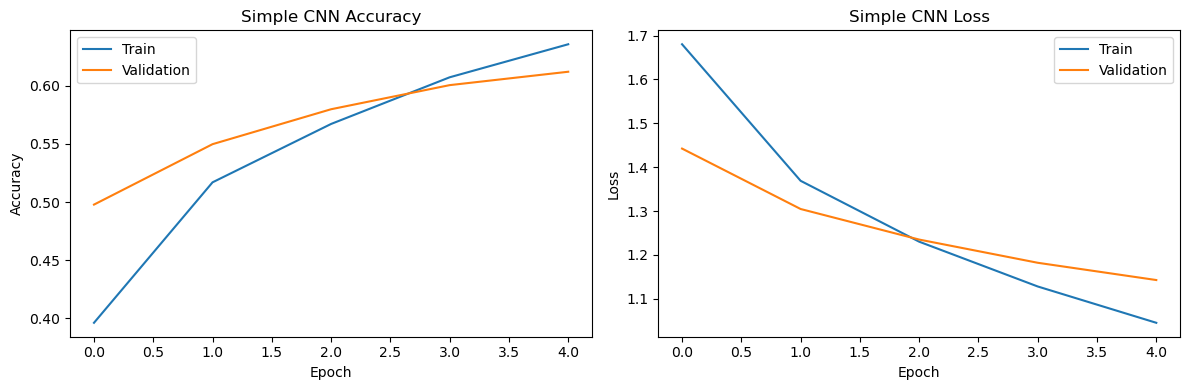

In [19]:
# Visualize training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train')
plt.plot(history_cnn.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Simple CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train')
plt.plot(history_cnn.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Simple CNN Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Add Data Augmentation *(10 points)*

Data augmentation creates variations of training images to improve generalization.

Build a **new CNN** with the **same architecture** as Question 3, then train it
using `ImageDataGenerator` with the following augmentations:
- `rotation_range=15` (rotate up to 15 degrees)
- `width_shift_range=0.1` (shift horizontally up to 10%)
- `height_shift_range=0.1` (shift vertically up to 10%)
- `horizontal_flip=True` (randomly flip horizontally)

Train for **5 epochs** with `batch_size=64`.

Store:
- **`model_aug`**: The augmented CNN model
- **`q6_aug_val_acc`**: Final validation accuracy, rounded to 3 decimals

**Hint:** Use `datagen.flow(X_train, y_train, batch_size=64)` in `model.fit()`.

In [20]:
# Build a new CNN model with the same architecture as Question 3
model_aug = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model (same as before)
model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Create an ImageDataGenerator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Fit the data generator on the training data
datagen.fit(X_train)

# Train the model with data augmentation
history_aug = model_aug.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=5,
    validation_data=(X_val, y_val)
)

# Get final validation accuracy
q6_aug_val_acc: float = round(history_aug.history['val_accuracy'][-1], 3)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2658 - loss: 1.9962 - val_accuracy: 0.3138 - val_loss: 1.9268
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.3591 - loss: 1.7627 - val_accuracy: 0.3839 - val_loss: 1.7526
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.3930 - loss: 1.6787 - val_accuracy: 0.4171 - val_loss: 1.6454
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.4125 - loss: 1.6233 - val_accuracy: 0.4255 - val_loss: 1.6517
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.4286 - loss: 1.5821 - val_accuracy: 0.4164 - val_loss: 1.6793


In [21]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert isinstance(model_aug, Sequential), (
    "model_aug should be a Keras Sequential model."
)
assert isinstance(q6_aug_val_acc, float), (
    "q6_aug_val_acc must be a float."
)
assert 0 <= q6_aug_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
# Verify it's a different model instance
assert model_aug is not model_cnn, (
    "model_aug should be a new model, not the same as model_cnn."
)
print(f"Augmented CNN validation accuracy: {q6_aug_val_acc:.3f}")

Augmented CNN validation accuracy: 0.416


## 7. Build a Deeper CNN with Batch Normalization *(10 points)*

Deeper networks can learn more complex features. Build a CNN with:

**Block 1:**
- Conv2D: 32 filters, 3×3, ReLU, same padding
- BatchNormalization
- MaxPooling2D: 2×2
- Dropout: 0.25

**Block 2:**
- Conv2D: 64 filters, 3×3, ReLU, same padding
- BatchNormalization
- MaxPooling2D: 2×2
- Dropout: 0.25

**Classification Head:**
- Flatten
- Dense: 64 neurons, ReLU
- Dropout: 0.5
- Dense: 10 neurons, Softmax

Train for **5 epochs** with `batch_size=64`.

Store:
- **`model_deep`**: The deep CNN model
- **`q7_deep_params`**: Total number of parameters (integer)
- **`q7_deep_val_acc`**: Final validation accuracy, rounded to 3 decimals

In [22]:
# Build the deep CNN model
model_deep = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Classification Head
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
model_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Get total number of trainable parameters
q7_deep_params: int = model_deep.count_params()

# Train the model
history_deep = model_deep.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

# Get final validation accuracy
q7_deep_val_acc: float = round(history_deep.history['val_accuracy'][-1], 3)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.1998 - loss: 2.1530 - val_accuracy: 0.3028 - val_loss: 1.9998
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.2664 - loss: 1.9465 - val_accuracy: 0.3875 - val_loss: 1.7365
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.3127 - loss: 1.8417 - val_accuracy: 0.4062 - val_loss: 1.6453
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.3357 - loss: 1.7740 - val_accuracy: 0.4247 - val_loss: 1.6242
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.3553 - loss: 1.7189 - val_accuracy: 0.4304 - val_loss: 1.6008


In [23]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert isinstance(model_deep, Sequential), (
    "model_deep should be a Keras Sequential model."
)
assert isinstance(q7_deep_params, (int, np.integer)), (
    "q7_deep_params must be an integer."
)
# Check for BatchNormalization
has_bn = any(isinstance(l, BatchNormalization) for l in model_deep.layers)
assert has_bn, (
    "Model should include BatchNormalization layers."
)
# Check for Dropout
has_dropout = any(isinstance(l, Dropout) for l in model_deep.layers)
assert has_dropout, (
    "Model should include Dropout layers."
)
# Count conv layers
conv_count = sum(1 for l in model_deep.layers if isinstance(l, Conv2D))
assert conv_count >= 2, (
    f"Model should have at least 2 Conv2D layers, got {conv_count}."
)
assert q7_deep_params > q3_n_params, (
    "Deep model should have more parameters than simple CNN."
)
assert isinstance(q7_deep_val_acc, float), (
    "q7_deep_val_acc must be a float."
)
assert 0 <= q7_deep_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
print(f"Deep CNN parameters: {q7_deep_params:,}")
print(f"Deep CNN validation accuracy: {q7_deep_val_acc:.3f}")
model_deep.summary()

Deep CNN parameters: 282,634
Deep CNN validation accuracy: 0.430


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,520 (3.23 MB)

 Trainable params: 282,442 (1.08 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 564,886 (2.15 MB)

## 8. Confusion Matrix Analysis *(10 points)*

A confusion matrix shows how predictions are distributed across classes, helping
identify which classes are commonly confused with each other.

Using the **deep CNN from Question 7** (`model_deep`):

1. Make predictions on the **test set** (`X_test`)
2. Convert predictions to class labels using `np.argmax(predictions, axis=1)`
3. Compute the confusion matrix using `confusion_matrix(y_test, y_pred_classes)`
4. Find the pair of classes that are most often confused (highest off-diagonal value)

Store:
- **`q8_conf_matrix`**: The 10x10 confusion matrix (numpy array)
- **`q8_most_confused`**: Tuple of (true_class, predicted_class) for the most confused pair

In [24]:
# Make predictions on the test set
y_pred_proba = model_deep.predict(X_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_proba, axis=1)

# Compute the confusion matrix
q8_conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Find the most confused pair of classes
# Initialize variables to track the maximum confusion and the corresponding classes
max_confusion = 0
q8_most_confused = None

# Iterate through the confusion matrix (excluding diagonal for 'off-diagonal' errors)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j:  # Only consider off-diagonal elements (actual class i, predicted class j)
            if q8_conf_matrix[i, j] > max_confusion:
                max_confusion = q8_conf_matrix[i, j]
                q8_most_confused = (i, j)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [25]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
assert isinstance(q8_conf_matrix, np.ndarray), (
    "q8_conf_matrix must be a numpy array. Use confusion_matrix() from sklearn."
)
assert q8_conf_matrix.shape == (10, 10), (
    f"Confusion matrix should be 10x10, got {q8_conf_matrix.shape}. "
    "Make sure you have 10 classes."
)
assert np.sum(q8_conf_matrix) == len(y_test), (
    "Confusion matrix values should sum to the number of test samples."
)
assert isinstance(q8_most_confused, tuple) and len(q8_most_confused) == 2, (
    "q8_most_confused must be a tuple of (true_class, predicted_class)."
)
assert q8_most_confused[0] != q8_most_confused[1], (
    "Most confused pair should be different classes (off-diagonal)."
)
print(f"Confusion matrix shape: {q8_conf_matrix.shape}")
print(f"Most confused pair: {CLASS_NAMES[q8_most_confused[0]]} confused with {CLASS_NAMES[q8_most_confused[1]]}")
print(f"Number of confusions: {q8_conf_matrix[q8_most_confused[0], q8_most_confused[1]]}")

Confusion matrix shape: (10, 10)
Most confused pair: cat confused with dog
Number of confusions: 461


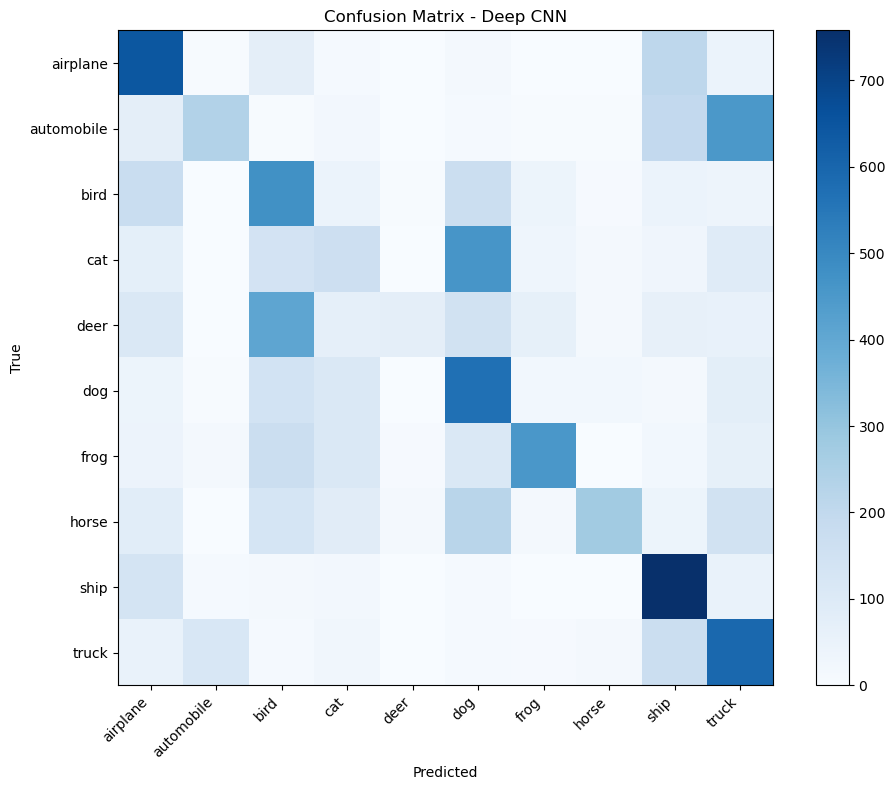

In [26]:
# Visualize the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(q8_conf_matrix, cmap='Blues')
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Deep CNN')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 9. Compare All Models on Test Set *(10 points)*

Evaluate all three CNN models on the **test set** and compare their performance.

Store a dictionary **`q9_test_accuracies`** with keys:
- `'simple_cnn'`: Test accuracy of the simple CNN (Q3)
- `'augmented'`: Test accuracy of the augmented CNN (Q6)
- `'deep'`: Test accuracy of the deep CNN (Q7)

All values should be floats rounded to 3 decimals.

Also store **`q9_best_model`**: The key of the model with highest test accuracy.

In [27]:
# Evaluate the simple CNN model on the test set
loss_cnn, acc_cnn = model_cnn.evaluate(X_test, y_test, verbose=0)

# Evaluate the augmented CNN model on the test set
loss_aug, acc_aug = model_aug.evaluate(X_test, y_test, verbose=0)

# Evaluate the deep CNN model on the test set
loss_deep, acc_deep = model_deep.evaluate(X_test, y_test, verbose=0)

# Store test accuracies
q9_test_accuracies: Dict[str, float] = {
    'simple_cnn': round(acc_cnn, 3),
    'augmented': round(acc_aug, 3),
    'deep': round(acc_deep, 3)
}

# Find the best model
q9_best_model: str = max(q9_test_accuracies, key=q9_test_accuracies.get)


In [28]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 9
assert isinstance(q9_test_accuracies, dict), (
    "q9_test_accuracies must be a dictionary."
)
expected_keys = {'simple_cnn', 'augmented', 'deep'}
assert set(q9_test_accuracies.keys()) == expected_keys, (
    f"Dictionary should have keys: {expected_keys}. Got: {set(q9_test_accuracies.keys())}"
)
for key, val in q9_test_accuracies.items():
    assert isinstance(val, float), f"Value for '{key}' must be a float."
    assert 0 <= val <= 1, f"Accuracy for '{key}' must be between 0 and 1."
assert isinstance(q9_best_model, str), (
    "q9_best_model must be a string (the model name)."
)
assert q9_best_model in expected_keys, (
    f"q9_best_model must be one of {expected_keys}."
)
print("Test Accuracies:")
for name, acc in sorted(q9_test_accuracies.items(), key=lambda x: -x[1]):
    marker = " <-- BEST" if name == q9_best_model else ""
    print(f"  {name}: {acc:.3f}{marker}")

Test Accuracies:
  simple_cnn: 0.604 <-- BEST
  deep: 0.424
  augmented: 0.420


## 10. Visualize Learned Filters *(10 points)*

CNNs learn meaningful filters (feature detectors) from data.

Extract and visualize the filters from the **first Conv2D layer** of the simple CNN:

1. Get the weights from the first convolutional layer
2. The weights have shape `(filter_height, filter_width, input_channels, num_filters)`
   For our model: `(3, 3, 3, 32)`
3. Store the shape of these weights in **`q10_filter_shape`**

Then visualize the first 8 filters.

In [29]:
# Get the weights from the first convolutional layer of model_cnn
first_conv_layer_weights = model_cnn.layers[0].get_weights()[0]

# Store the shape of these weights
q10_filter_shape: Tuple[int, int, int, int] = first_conv_layer_weights.shape

# Print the answer as requested
print(f"q10_filter_shape: {q10_filter_shape}")


q10_filter_shape: (3, 3, 3, 32)


In [30]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 10
assert isinstance(q10_filter_shape, tuple), (
    "q10_filter_shape must be a tuple."
)
assert len(q10_filter_shape) == 4, (
    "Filter shape should be 4D: (height, width, input_channels, num_filters)."
)
assert all(isinstance(x, (int, np.integer)) and x > 0 for x in q10_filter_shape), (
    "All dimensions must be positive integers."
)
print(f"First conv layer filter shape: {q10_filter_shape}")
print(f"  Filter size: {q10_filter_shape[0]}×{q10_filter_shape[1]}")
print(f"  Input channels: {q10_filter_shape[2]}")
print(f"  Number of filters: {q10_filter_shape[3]}")

First conv layer filter shape: (3, 3, 3, 32)
  Filter size: 3×3
  Input channels: 3
  Number of filters: 32


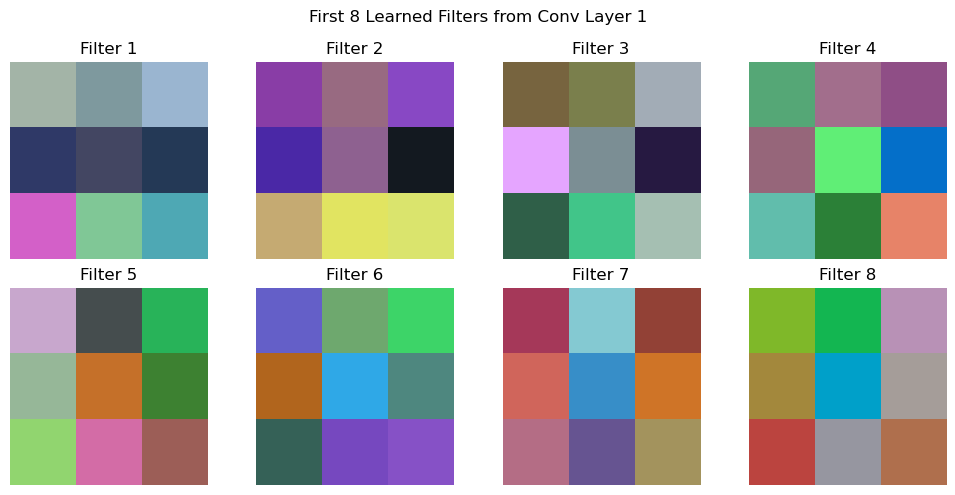

In [31]:
# Visualize the first 8 learned filters
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

# Get filters
first_conv_layer = model_cnn.layers[0]
filters, biases = first_conv_layer.get_weights()

# Normalize filters for visualization
filters_normalized = (filters - filters.min()) / (filters.max() - filters.min())

for idx, ax in enumerate(axes.flat):
    if idx < 8:
        # Get the filter (3x3x3) and display as RGB image
        f = filters_normalized[:, :, :, idx]
        ax.imshow(f)
        ax.set_title(f'Filter {idx+1}')
    ax.axis('off')

plt.suptitle('First 8 Learned Filters from Conv Layer 1')
plt.tight_layout()
plt.show()


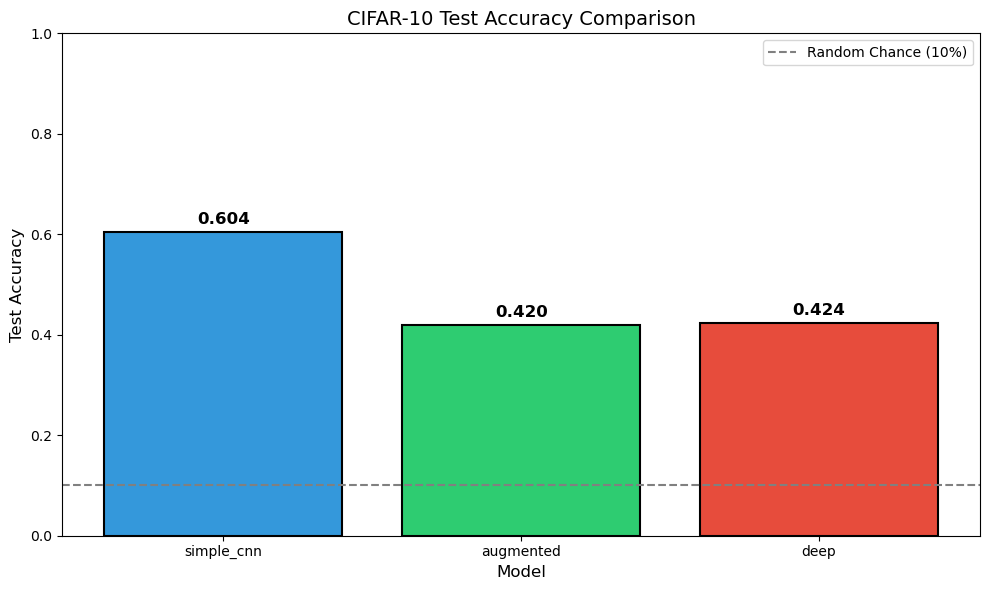

In [32]:
# Summary comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

models = list(q9_test_accuracies.keys())
accuracies = [q9_test_accuracies[m] for m in models]

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = ax.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('CIFAR-10 Test Accuracy Comparison', fontsize=14)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.1, color='gray', linestyle='--', label='Random Chance (10%)')
ax.legend()

plt.tight_layout()
plt.show()

## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.
